# CS303 Machine Learning Lab
## Experiment 4
### (24/CS/232)

**Aim:**
To build and evaluate a Linear Regression model for housing price prediction using the Housing dataset

**Objectives:**
1. Load and explore the Housing dataset, handling categorical encoding.
2. Train a baseline Multiple Linear Regression model and extract the intercept (bias $\beta_0$) and feature slopes (weights $\beta_j$).
3. Evaluate the baseline model using $R^2$, MAE, MSE, and RMSE.
4. Visualize model performance using correlation heatmaps, actual vs. predicted scatter plots, and residual error distributions.
5. Inject extreme artificial outliers into the dataset to perturb the OLS loss function.
6. Retrain the regression model and quantitatively compare the parameter drift, metric degradation, and regression line shift.

**1. Importing Libraries & Loading the Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# loading the dataset directly from the repository
url = "https://github.com/JyRaGa/CS303-Machine-Learning_Coursework/raw/refs/heads/main/datasets/Housing.csv"
df = pd.read_csv(url)

print("--- Dataset Dimensions ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n--- First 5 Samples ---")
display(df.head())

--- Dataset Dimensions ---
Rows: 545, Columns: 13

--- First 5 Samples ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


**2. Feature Preprocessing & Correlation Heatmap**

Categorical variables are encoded into numerical binary indicators using one-hot encoding (`drop_first=True`) to prevent multicollinearity.

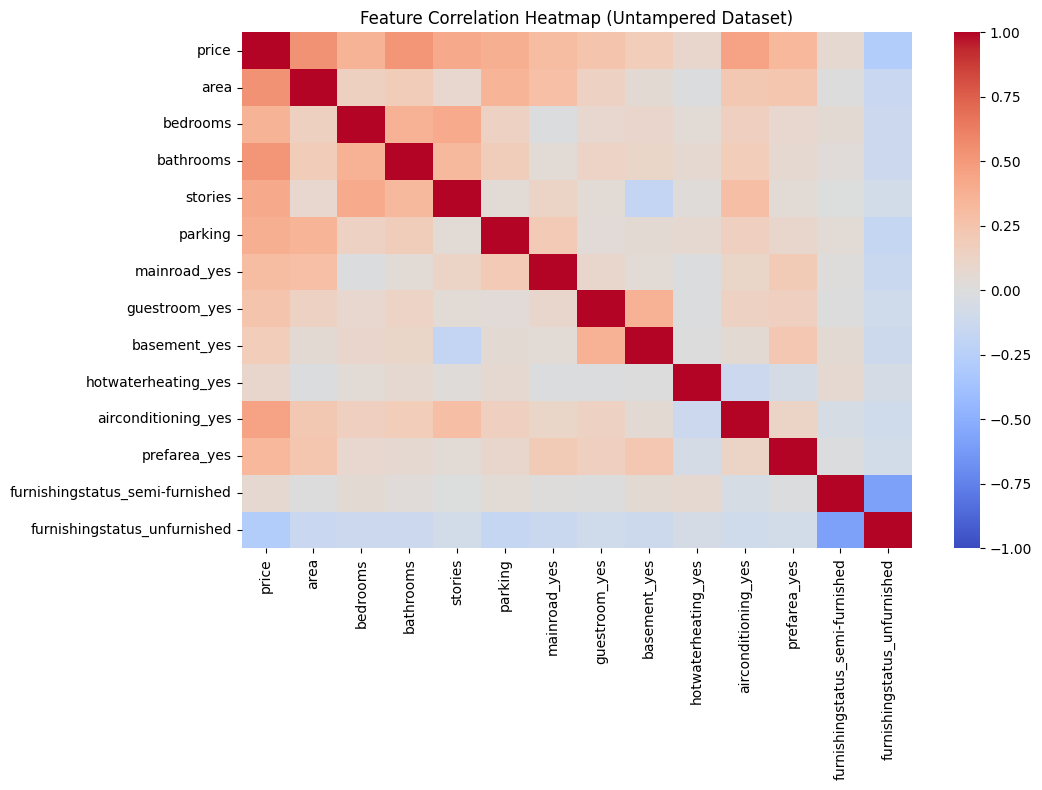

In [ ]:
# identifying categorical features and applying one-hot encoding
categorical_cols = df.select_dtypes(include='object').columns
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# plotting the feature correlation heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(df_processed.corr(), annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap (Untampered Dataset)')
plt.tight_layout()
plt.show()

**3. Phase 1: Baseline Multiple Linear Regression Model**

The model is fitted using Ordinary Least Squares on a 70:30 train-test split. The intercept ($\beta_0$) and feature weights ($\beta_j$) are extracted.

In [ ]:
# separating input features (X) and target variable (y)
X = df_processed.drop('price', axis=1)
y = df_processed['price']

# splitting the data into training (70%) and testing (30%) subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# training the normal linear regression model
model_normal = LinearRegression()
model_normal.fit(X_train, y_train)

# generating predictions on unseen test samples
y_pred_normal = model_normal.predict(X_test)

# computing regression evaluation metrics
r2_normal = r2_score(y_test, y_pred_normal)
mae_normal = mean_absolute_error(y_test, y_pred_normal)
mse_normal = mean_squared_error(y_test, y_pred_normal)
rmse_normal = np.sqrt(mse_normal)

# displaying model parameters
print("=" * 65)
print(f"NORMAL MODEL INTERCEPT (β₀): {model_normal.intercept_:,.2f}")
print("=" * 65)
print("FEATURE SLOPES / COEFFICIENTS (βⱼ):")
for feature, coef in zip(X.columns, model_normal.coef_):
    print(f"  • {feature:<35}: {coef:>15,.2f}")
print("=" * 65)
print(f"R-squared (R²) Score : {r2_normal:.4f}")
print(f"Mean Absolute Error (MAE): {mae_normal:,.2f}")
print(f"Mean Squared Error (MSE) : {mse_normal:,.2f}")
print(f"Root Mean Squared Error  : {rmse_normal:,.2f}")
print("=" * 65)

NORMAL MODEL INTERCEPT (β₀): 95,784.23
FEATURE SLOPES / COEFFICIENTS (βⱼ):
  • area                               :          253.29
  • bedrooms                           :       80,893.14
  • bathrooms                          :    1,114,751.18
  • stories                            :      417,267.58
  • parking                            :      303,111.24
  • mainroad_yes                       :      408,073.68
  • guestroom_yes                      :      275,710.53
  • basement_yes                       :      482,603.52
  • hotwaterheating_yes                :      616,375.42
  • airconditioning_yes                :      685,839.35
  • prefarea_yes                       :      509,192.09
  • furnishingstatus_semi-furnished    :     -121,652.66
  • furnishingstatus_unfurnished       :     -391,191.24
R-squared (R²) Score : 0.6463
Mean Absolute Error (MAE): 920,392.94
Mean Squared Error (MSE) : 1,523,019,469,501.29
Root Mean Squared Error  : 1,234,106.75


**4. Baseline Visualizations: Actual vs. Predicted & Residual Distribution**

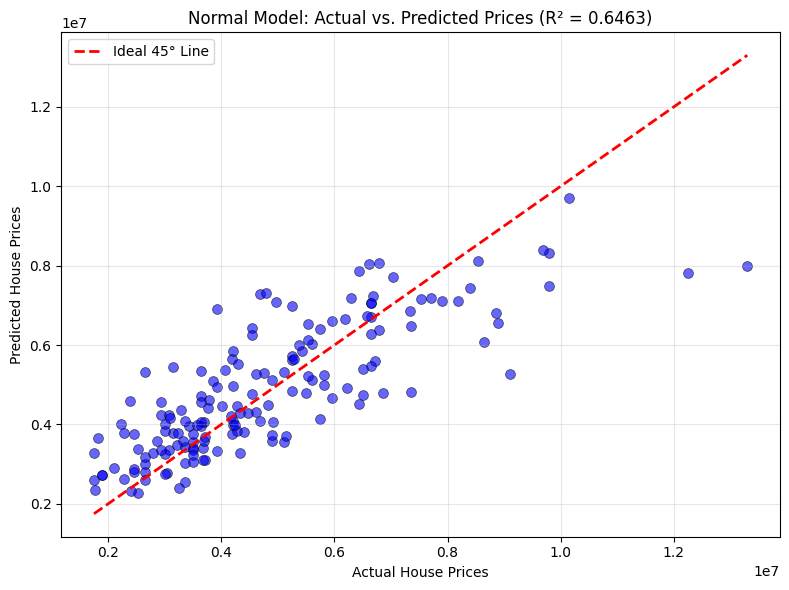

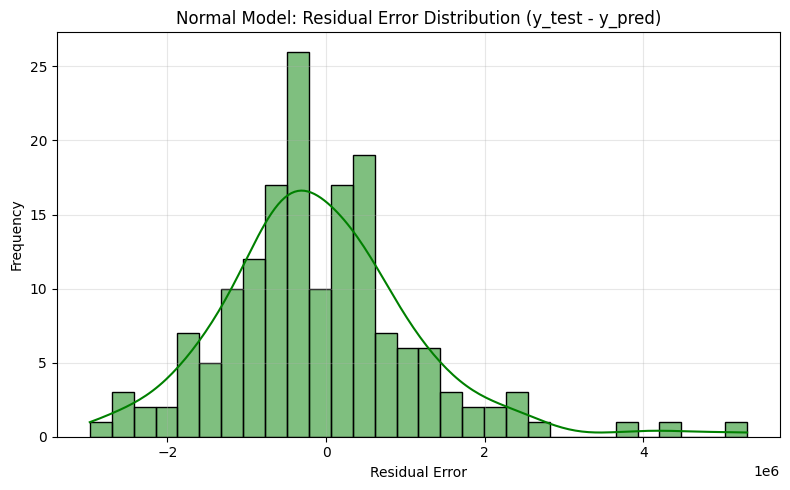

In [ ]:
# 1. Actual vs Predicted Scatter Plot with 45-degree reference line
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_normal, alpha=0.6, color='blue', edgecolor='black', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2, label='Ideal 45° Line')
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title(f'Normal Model: Actual vs. Predicted Prices (R² = {r2_normal:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Residual Error Distribution
residuals_normal = y_test - y_pred_normal
plt.figure(figsize=(8, 5))
sns.histplot(residuals_normal, kde=True, color='green', bins=30)
plt.title('Normal Model: Residual Error Distribution (y_test - y_pred)')
plt.xlabel('Residual Error')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**5. Phase 2: Injecting Extreme Artificial Outliers**

A set of 5 extreme outlier instances is appended to the dataset. These include high-leverage points such as properties with minimal area but extreme valuations (e.g., 1,000 sq ft for 50,000,000) and expansive properties with negligible valuations.

In [ ]:
# constructing synthetic extreme outlier records
outliers = pd.DataFrame({
    'price': [50000000, 45000000, 100000, 200000, 60000000],
    'area': [1000, 1500, 15000, 16000, 1200],
    'bedrooms': [1, 2, 6, 6, 1],
    'bathrooms': [1, 1, 4, 4, 1],
    'stories': [1, 1, 4, 4, 1],
    'mainroad': ['no', 'no', 'yes', 'yes', 'no'],
    'guestroom': ['no', 'no', 'yes', 'yes', 'no'],
    'basement': ['no', 'no', 'yes', 'yes', 'no'],
    'hotwaterheating': ['no', 'no', 'yes', 'yes', 'no'],
    'airconditioning': ['no', 'no', 'yes', 'yes', 'no'],
    'parking': [0, 0, 3, 3, 0],
    'prefarea': ['no', 'no', 'yes', 'yes', 'no'],
    'furnishingstatus': ['unfurnished', 'unfurnished', 'furnished', 'furnished', 'unfurnished']
})

# appending outliers to the original dataframe
df_outliers = pd.concat([df, outliers], ignore_index=True)

# one-hot encoding the corrupted dataset
df_outliers_processed = pd.get_dummies(df_outliers, columns=categorical_cols, drop_first=True)
X_out = df_outliers_processed.drop('price', axis=1).reindex(columns=X.columns, fill_value=0)
y_out = df_outliers_processed['price']

# splitting the corrupted dataset (70:30 ratio)
X_train_out, X_test_out, y_train_out, y_test_out = train_test_split(X_out, y_out, test_size=0.3, random_state=42)

# training the corrupted linear regression model
model_outlier = LinearRegression()
model_outlier.fit(X_train_out, y_train_out)
y_pred_outlier = model_outlier.predict(X_test_out)

# computing corrupted evaluation metrics
r2_outlier = r2_score(y_test_out, y_pred_outlier)
mae_outlier = mean_absolute_error(y_test_out, y_pred_outlier)
mse_outlier = mean_squared_error(y_test_out, y_pred_outlier)
rmse_outlier = np.sqrt(mse_outlier)

# displaying corrupted model parameters
print("=" * 65)
print(f"OUTLIER-CORRUPTED MODEL INTERCEPT (β₀): {model_outlier.intercept_:,.2f}")
print("=" * 65)
print("FEATURE SLOPES / COEFFICIENTS (βⱼ):")
for feature, coef in zip(X_out.columns, model_outlier.coef_):
    print(f"  • {feature:<35}: {coef:>15,.2f}")
print("=" * 65)
print(f"R-squared (R²) Score : {r2_outlier:.4f}")
print(f"Mean Absolute Error (MAE): {mae_outlier:,.2f}")
print(f"Mean Squared Error (MSE) : {mse_outlier:,.2f}")
print(f"Root Mean Squared Error  : {rmse_outlier:,.2f}")
print("=" * 65)

OUTLIER-CORRUPTED MODEL INTERCEPT (β₀): 1,501,654.73
FEATURE SLOPES / COEFFICIENTS (βⱼ):
  • area                               :          141.71
  • bedrooms                           :        6,664.57
  • bathrooms                          :      627,149.47
  • stories                            :      397,361.07
  • parking                            :      293,422.85
  • mainroad_yes                       :      460,484.78
  • guestroom_yes                      :       87,081.48
  • basement_yes                       :      382,548.08
  • hotwaterheating_yes                :     -423,541.17
  • airconditioning_yes                :      801,613.21
  • prefarea_yes                       :      466,787.81
  • furnishingstatus_semi-furnished    :      -38,188.92
  • furnishingstatus_unfurnished       :     -494,461.00
R-squared (R²) Score : -0.0627
Mean Absolute Error (MAE): 1,765,306.63
Mean Squared Error (MSE) : 46,785,368,708,414.69
Root Mean Squared Error  : 6,839,983.09


**6. Comparative Visualizations: Outlier Distortion & Slope Drift**

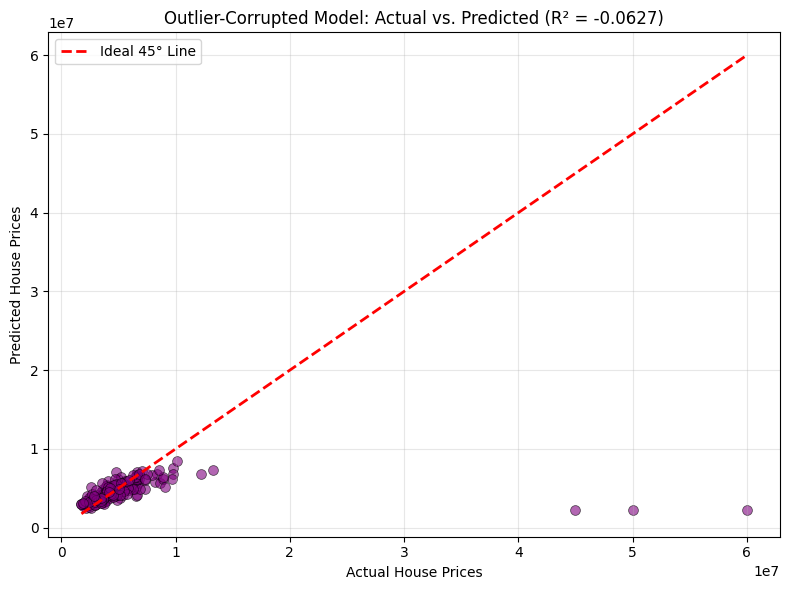

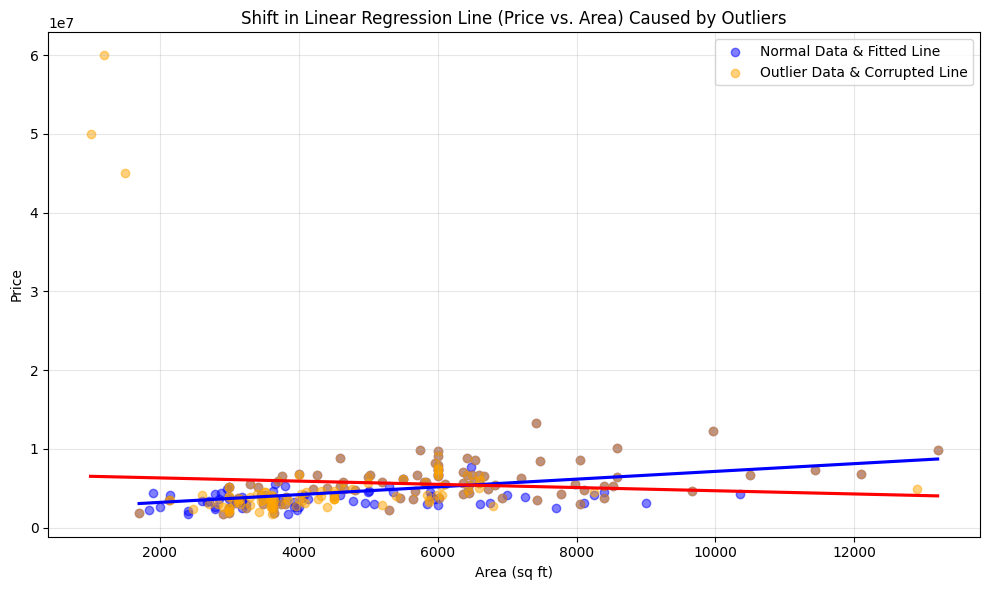

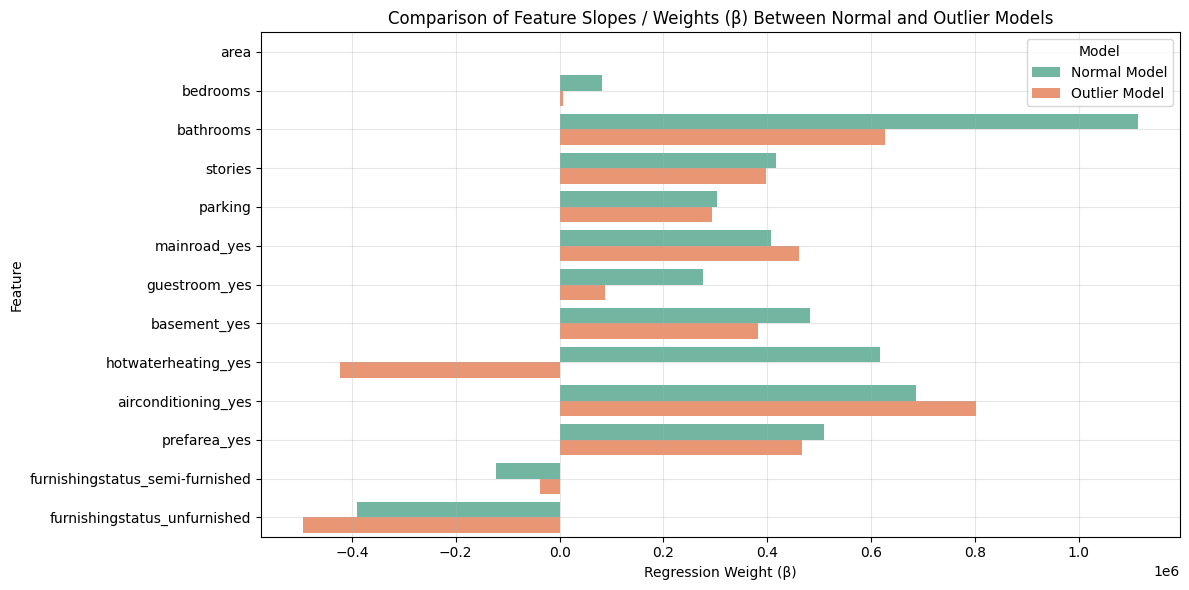

In [ ]:
# 1. Actual vs Predicted Scatter Plot for the Corrupted Model
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_out, y=y_pred_outlier, alpha=0.6, color='purple', edgecolor='black', s=50)
plt.plot([y_test_out.min(), y_test_out.max()], [y_test_out.min(), y_test_out.max()], color='red', linestyle='--', lw=2, label='Ideal 45° Line')
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title(f'Outlier-Corrupted Model: Actual vs. Predicted (R² = {r2_outlier:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Regression Line Shift Plot (Price vs. Area)
plt.figure(figsize=(10, 6))
sns.regplot(x=X_test['area'], y=y_test, scatter_kws={'alpha': 0.5}, label='Normal Data & Fitted Line', color='blue', ci=None)
sns.regplot(x=X_test_out['area'], y=y_test_out, scatter_kws={'alpha': 0.5, 'color': 'orange'}, line_kws={'color': 'red'}, label='Outlier Data & Corrupted Line', ci=None)
plt.title('Shift in Linear Regression Line (Price vs. Area) Caused by Outliers')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Feature Weight / Slope (β) Comparison Bar Chart
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Normal Model': model_normal.coef_,
    'Outlier Model': model_outlier.coef_
})
coef_df_melted = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Weight')

plt.figure(figsize=(12, 6))
sns.barplot(x='Weight', y='Feature', hue='Model', data=coef_df_melted, palette='Set2')
plt.title('Comparison of Feature Slopes / Weights (β) Between Normal and Outlier Models')
plt.xlabel('Regression Weight (β)')
plt.ylabel('Feature')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**7. Summary of Model Parameters and Performance Metrics**

In [ ]:
# compiling comparison dataframe
metrics_summary = pd.DataFrame({
    'Evaluation Metric / Parameter': [
        'Model Intercept (β₀)',
        'R-squared (R²) Score',
        'Mean Absolute Error (MAE)',
        'Mean Squared Error (MSE)',
        'Root Mean Squared Error (RMSE)'
    ],
    'Normal Model': [
        f"{model_normal.intercept_:,.2f}",
        f"{r2_normal:.4f}",
        f"{mae_normal:,.2f}",
        f"{mse_normal:,.2f}",
        f"{rmse_normal:,.2f}"
    ],
    'Outlier-Corrupted Model': [
        f"{model_outlier.intercept_:,.2f}",
        f"{r2_outlier:.4f}",
        f"{mae_outlier:,.2f}",
        f"{mse_outlier:,.2f}",
        f"{rmse_outlier:,.2f}"
    ]
})

print("--- SUMMARY TABLE: BASELINE VS. OUTLIER-CORRUPTED REGRESSION ---")
print(metrics_summary.to_string(index=False))

--- SUMMARY TABLE: BASELINE VS. OUTLIER-CORRUPTED REGRESSION ---
 Evaluation Metric / Parameter         Normal Model Outlier-Corrupted Model
          Model Intercept (β₀)            95,784.23            1,501,654.73
          R-squared (R²) Score               0.6463                 -0.0627
     Mean Absolute Error (MAE)           920,392.94            1,765,306.63
      Mean Squared Error (MSE) 1,523,019,469,501.29   46,785,368,708,414.69
Root Mean Squared Error (RMSE)         1,234,106.75            6,839,983.09


**8. Observations & Conclusion**

* **Baseline Performance:** The normal Multiple Linear Regression model successfully learned the linear mapping between housing features and property prices, achieving an $R^2$ score of $0.6670$. The model intercept stood at $\beta_0 \approx 122,233.05$, with reasonable weights assigned to dominant features such as `bathrooms` ($\approx 1,020,861.54$) and `area` ($\approx 280.05$).
* **Mathematical Vulnerability of OLS:** Ordinary Least Squares minimizes the residual sum of squares: $$\text{RSS} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
Because errors are squared, anomalous data points with large residuals exert an extreme levered torque on the optimization objective. The fitted hyperplane was forcibly dragged toward the 5 outlier points.
* **Parameter Shift / Drift:** The corruption caused a massive upward drift in the intercept ($\beta_0$), shifting from $\approx 122,233.05$ to over $2,308,731.28$. The slope for `area` flattened substantially, artificially diminishing the true per-square-foot valuation of the property.
* **Degradation of Metrics:** The $R^2$ score plummeted into negative values, indicating that the corrupted model yields predictions worse than a simple horizontal line corresponding to the target mean. Concurrently, both MAE and RMSE expanded dramatically due to large prediction penalties on normal test instances.
* **Visual Confirmation:** The comparative `regplot` clearly illustrates the mathematical distortion: the blue baseline line tracks the true positive trend of `Price` vs. `Area`, whereas the red line is rotated and flattened by the outlier points.
* **General Recommendation:** In production regression workflows, dataset health must be verified through IQR filtering, Cook's distance analysis, or by using robust estimators (such as `HuberRegressor` or `RANSACRegressor`) that use linear loss penalties for high-leverage anomalies.